# MMDL: Multi-Modal TMB Prediction from Histopathology + Clinical Data
## DSAI 305 Phase 2 - Explainable AI Project
#
**Model**: Multi-Modal Deep Learning (MMDL) - Huang et al., Bioinformatics 2022
**Task**: Binary TMB classification (High ≥20 mut/Mb vs Low <20 mut/Mb)
**Framework**: PyTorch 2.0.1
**Modalities**: H&E image tiles (512×512) + Clinical tabular features
**Explainability**: SHAP (image+tabular), LIME, PDP/ICE, Grad-CAM, Feature Importance


In [1]:
# ## §1 — Imports & Environment Setup

import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings('ignore')

# PyTorch & Torchvision
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms
from torchvision import models

# Explainability libraries
import shap
from lime import lime_image, lime_tabular
from skimage.segmentation import mark_boundaries
import cv2

# Metrics & stats
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.ensemble import RandomForestClassifier
from scipy import stats

# Reproducibility
SEEDS = [42]


def set_seed(seed: int):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


/home/youssef_mohammad/projects/DSAI_305_XAI_PROJECT/DSAI_305_XAI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# ## §2 — Configuration & Paths

# Project root (relative paths from here)
PROJECT_ROOT = Path(__file__).parent.parent.parent.parent if '__file__' in dir() else Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

# Data paths
DATA_DIR = PROJECT_ROOT / 'data'
TILES_DIR = DATA_DIR / 'processed' / 'tiles'
TABULAR_DIR = DATA_DIR / 'cbioportal_tabular_downloads'
CHECKPOINT_DIR = Path('members/youssef/experiments/MultiModal/checkpoints')
FIGURES_DIR = Path('members/youssef/experiments/MultiModal/figures')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Hyperparameters (from paper + project requirements)
CONFIG = {
    # Image settings
    'input_size': 512,  # Paper uses 512×512 tiles
    'tile_resize': 224,  # Resize for ResNet18 input

    # Training settings
    'batch_size': 64,
    'learning_rate': 1e-4,
    'optimizer': 'adamw',
    'weight_decay': 1e-4,
    'dropout': 0.2,
    'epochs': 30,
    'patience': 10,
    'factor': 0.5,
    'min_lr': 1e-7,

    # Classification settings
    'num_classes': 2,
    'tmb_threshold': 20.0,  # Paper: 14.3% percentile ≈ 20 mut/Mb

    # MCB pooling settings
    'mcb_output_dim': 8000,  # Compact bilinear output dimension
    'mcb_sketch_dim': 10000,  # Count sketch dimension

    # Clinical feature settings
    'top_clinical_features': ['tumor_stage', 'pathologic_T', 'pathologic_N',
                              'pathologic_M', 'age'],  # Top 5 from paper Fig 4b
}

print(f"Configuration loaded: {CONFIG}")



Configuration loaded: {'input_size': 512, 'tile_resize': 224, 'batch_size': 64, 'learning_rate': 0.0001, 'optimizer': 'adamw', 'weight_decay': 0.0001, 'dropout': 0.2, 'epochs': 30, 'patience': 10, 'factor': 0.5, 'min_lr': 1e-07, 'num_classes': 2, 'tmb_threshold': 20.0, 'mcb_output_dim': 8000, 'mcb_sketch_dim': 10000, 'top_clinical_features': ['tumor_stage', 'pathologic_T', 'pathologic_N', 'pathologic_M', 'age']}


In [3]:
# ## §3 — Multi-Modal Compact Bilinear (MCB) Pooling

class CountSketch(nn.Module):
    """Count sketch projection for compact bilinear pooling."""

    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim

        # Random projection matrices (fixed for reproducibility)
        self.register_buffer('h', torch.randint(0, output_dim, (input_dim,)))
        self.register_buffer('s', torch.randn(input_dim).sign())

    def forward(self, x):
        """Apply count sketch: x ∈ (B, input_dim) → (B, output_dim)"""
        B = x.size(0)
        sketch = x.new_zeros(B, self.output_dim)

        # Vectorized count sketch
        h_expanded = self.h.unsqueeze(0).expand(B, -1)
        s_expanded = self.s.unsqueeze(0).expand(B, -1)

        # Scatter add: sketch[b, h[i]] += s[i] * x[b, i]
        sketch.scatter_add_(1, h_expanded, s_expanded * x)
        return sketch


class CompactBilinearPooling(nn.Module):
    """
    Multi-modal Compact Bilinear (MCB) pooling.
    Fuses two feature vectors via randomized sketching + FFT convolution.
    Reference: Fukui et al., 2016; Gao et al., 2016
    """

    def __init__(self, input_dim1, input_dim2, output_dim, sum_pool=True):
        super().__init__()
        self.input_dim1 = input_dim1
        self.input_dim2 = input_dim2
        self.output_dim = output_dim
        self.sum_pool = sum_pool

        self.sketch1 = CountSketch(input_dim1, output_dim)
        self.sketch2 = CountSketch(input_dim2, output_dim)

        # Optional: learnable projection after pooling
        self.proj = nn.Linear(output_dim, output_dim // 10)
        self.bn = nn.BatchNorm1d(output_dim // 10)

    def forward(self, x1, x2):
        """
        Args:
            x1: Features from modality 1 (B, input_dim1)
            x2: Features from modality 2 (B, input_dim2)
        Returns:
            fused: Compact bilinear representation (B, output_dim//10)
        """
        # Count sketch projections
        sketch1 = self.sketch1(x1)
        sketch2 = self.sketch2(x2)

        # FFT-based convolution in frequency domain using modern torch.fft
        fft1 = torch.fft.rfft(sketch1, dim=1)
        fft2 = torch.fft.rfft(sketch2, dim=1)

        # Complex multiplication in frequency domain
        fft_product = fft1 * fft2

        # Inverse FFT to get convolution result
        conv = torch.fft.irfft(fft_product, n=self.output_dim, dim=1)

        # Signed square root normalization + L2 normalization
        conv = torch.sign(conv) * torch.sqrt(torch.abs(conv) + 1e-8)
        conv = F.normalize(conv, p=2, dim=1)

        # Optional projection for dimensionality reduction
        if self.proj is not None:
            conv = self.proj(conv)
            conv = self.bn(conv)
            conv = F.relu(conv)

        return conv



In [4]:
# ## §4 — MMDL Architecture: ResNet18 + Clinical Fusion

class MMDL(nn.Module):
    """
    Multi-Modal Deep Learning model for TMB prediction.

    Architecture:
    1. Image branch: ResNet18 (pretrained on ImageNet) → global avg pool → 512-d features
    2. Clinical branch: MLP → 128-d features
    3. Fusion: Compact Bilinear Pooling (MCB) → 800-d fused representation
    4. Classifier: FC layers → binary output
    """

    def __init__(self, num_clinical_features: int, num_classes: int = 2,
                 pretrained: bool = True):
        super().__init__()

        # === Image Branch: ResNet18 ===
        self.image_backbone = models.resnet18(pretrained=pretrained)
        # Remove final FC layer
        self.image_backbone.fc = nn.Identity()
        image_feat_dim = 512  # ResNet18 output dimension

        # === Clinical Branch: MLP ===
        clinical_hidden = 128
        self.clinical_mlp = nn.Sequential(
            nn.Linear(num_clinical_features, clinical_hidden),
            nn.BatchNorm1d(clinical_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(CONFIG['dropout']),
            nn.Linear(clinical_hidden, clinical_hidden),
            nn.BatchNorm1d(clinical_hidden),
            nn.ReLU(inplace=True),
        )

        # === Fusion: Compact Bilinear Pooling ===
        self.mcb = CompactBilinearPooling(
            input_dim1=image_feat_dim,
            input_dim2=clinical_hidden,
            output_dim=CONFIG['mcb_output_dim'],
            sum_pool=True
        )
        fused_dim = CONFIG['mcb_output_dim'] // 10

        # === Classification Head ===
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(CONFIG['dropout']),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_classes),
        )

        # Store feature names for explainability
        self.clinical_feature_names = None

    def set_clinical_features(self, feature_names: list):
        """Set clinical feature names for SHAP/LIME interpretability."""
        self.clinical_feature_names = feature_names

    def forward(self, images: torch.Tensor, clinical: torch.Tensor) -> tuple:
        """
        Args:
            images: (B, 3, H, W) normalized RGB tiles
            clinical: (B, num_clinical_features) tabular data
        Returns:
            logits: (B, num_classes) classification scores
            image_features: (B, 512) for Grad-CAM
            clinical_features: (B, 128) for tabular XAI
        """
        # Image features
        image_features = self.image_backbone(images)  # (B, 512)

        # Clinical features
        clinical_features = self.clinical_mlp(clinical)  # (B, 128)

        # Multimodal fusion via MCB
        fused = self.mcb(image_features, clinical_features)  # (B, 800)

        # Classification
        logits = self.classifier(fused)  # (B, 2)

        return logits, image_features, clinical_features



In [5]:
# ## §5 — Multi-Modal Dataset

class MMDLDataset(Dataset):
    """Dataset combining histology tiles + clinical tabular data."""

    def __init__(self, tiles_dir: Path, clinical_df: pd.DataFrame,
                 transform=None, mode: str = 'train'):
        self.tiles_dir = tiles_dir
        self.clinical_df = clinical_df.reset_index(drop=True)
        self.transform = transform
        self.mode = mode

        # Build index: (tile_path, clinical_row_idx, label, patient_id)
        self.samples = []
        clinical_dict = clinical_df.set_index('patient_id').to_dict('index')

        # Get available patient folders on disk
        available_patients = {p.name for p in tiles_dir.iterdir() if p.is_dir()}

        for patient_id in clinical_df['patient_id'].unique():
            # Only process patients with tiles on disk
            if patient_id not in available_patients:
                continue
            patient_tiles = []
            # Search for multiple tile formats: .png, .jpg, .jpeg, .tif, .tiff
            for pattern in ('*.png', '*.jpg', '*.jpeg', '*.tif', '*.tiff'):
                patient_tiles.extend(sorted((tiles_dir / patient_id).glob(pattern)))
            if patient_id not in clinical_dict:
                continue
            clinical_row = clinical_dict[patient_id]
            label = clinical_row.get('tmb_label')
            if label is None:
                continue
            for tile_path in patient_tiles:
                self.samples.append((str(tile_path), patient_id, label))

        # Extract clinical feature matrix
        self.clinical_features = clinical_df[CONFIG['top_clinical_features']].values
        self.clinical_feature_names = CONFIG['top_clinical_features']

        # Patient-to-index mapping for clinical lookup
        self.patient_to_idx = {pid: idx for idx, pid in
                               enumerate(clinical_df['patient_id'].unique())}

        # Compute class weights
        labels = [s[2] for s in self.samples]
        if labels:
            class_counts = np.bincount(labels, minlength=2)
            total = len(labels)
            self.class_weights = {
                cls: total / (2 * count) if count > 0 else 1.0
                for cls, count in enumerate(class_counts)
            }
        else:
            self.class_weights = {0: 1.0, 1: 1.0}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        tile_path, patient_id, label = self.samples[idx]

        # Load and preprocess image
        img = cv2.imread(tile_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (CONFIG['input_size'], CONFIG['input_size']))
        
        # Convert to PIL Image for torchvision transforms
        from PIL import Image
        img = Image.fromarray(img)

        # Resize to ResNet input size
        if self.transform:
            img = self.transform(img)
        
        # Ensure it's a tensor and normalized
        to_tensor = transforms.Compose([
            transforms.Resize(CONFIG['tile_resize']),
            transforms.CenterCrop(CONFIG['tile_resize']),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])
        img = to_tensor(img)

        # Get clinical features for this patient
        if patient_id in self.patient_to_idx:
            clin_idx = self.patient_to_idx[patient_id]
            clinical = self.clinical_features[clin_idx].astype(np.float32)
        else:
            # Fallback: zero vector if patient not in clinical df
            clinical = np.zeros(len(self.clinical_feature_names), dtype=np.float32)

        clinical = torch.from_numpy(clinical).float()

        return img, clinical, torch.tensor(label, dtype=torch.long), patient_id, tile_path


def create_dataloaders(tiles_dir: Path, clinical_df: pd.DataFrame,
                      batch_size: int, val_split: float = 0.2):
    """Create train/val/test dataloaders with patient-level splitting."""

    # Keep only patients that actually have tiles on disk
    available_patients = {p.name for p in tiles_dir.iterdir() if p.is_dir()}
    clinical_df = clinical_df[clinical_df['patient_id'].isin(available_patients)].copy()

    if clinical_df.empty:
        raise ValueError(
            f"No labeled patients match folders in {tiles_dir}. "
            "Check the demo label generation or label file patient IDs."
        )

    # Patient-level split
    patients = clinical_df['patient_id'].unique()
    np.random.shuffle(patients)

    if len(patients) < 3:
        raise ValueError(
            f"Need at least 3 matched patients for train/val/test splitting, got {len(patients)}."
        )

    n_val = max(1, int(len(patients) * val_split))
    n_test = max(1, int(len(patients) * val_split))

    # Ensure training set is not empty
    if len(patients) - (n_val + n_test) < 1:
        n_val = 1
        n_test = 1
        if len(patients) < 3:
             # Should be caught by the check above, but being safe
             pass

    test_patients = set(patients[:n_test])
    val_patients = set(patients[n_test:n_test + n_val])
    train_patients = set(patients[n_test + n_val:])

    # Create datasets
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    ])

    train_ds = MMDLDataset(tiles_dir, clinical_df, transform=transform_train, mode='train')
    val_ds = MMDLDataset(tiles_dir, clinical_df, mode='val')
    test_ds = MMDLDataset(tiles_dir, clinical_df, mode='test')

    # Filter by patient split
    def filter_by_patients(dataset, patient_set):
        dataset.samples = [s for s in dataset.samples if s[1] in patient_set]
        return dataset

    train_ds = filter_by_patients(train_ds, train_patients)
    val_ds = filter_by_patients(val_ds, val_patients)
    test_ds = filter_by_patients(test_ds, test_patients)

    if len(train_ds) == 0:
        raise ValueError(
            "Training split is empty after patient filtering. "
            "Verify label/patient ID alignment and the train/val/test split."
        )

    # Weighted sampler for imbalanced classes
    train_labels = [s[2] for s in train_ds.samples]
    sample_weights = [train_ds.class_weights[label] for label in train_labels]
    
    # Ensure num_samples is at least 1
    num_samples = len(sample_weights)
    sampler = WeightedRandomSampler(sample_weights, num_samples, replacement=True)

    # Create dataloaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                              num_workers=4, pin_memory=True, drop_last=True if len(train_ds) > batch_size else False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                             num_workers=4, pin_memory=True)

    return train_loader, val_loader, test_loader, train_ds.clinical_feature_names



In [6]:
# ## §6 — Training Pipeline (Same as CellMorphNet)

def train_epoch(model, loader, optimizer, criterion, device):
    """Single training epoch."""
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, clinical, labels, _, _ in tqdm(loader, desc='Training', leave=False):
        imgs, clinical, labels = imgs.to(device), clinical.to(device), labels.to(device)

        optimizer.zero_grad()
        logits, _, _ = model(imgs, clinical)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader) if len(loader) > 0 else 0, correct / total if total > 0 else 0


def validate(model, loader, criterion, device):
    """Validation epoch."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, clinical, labels, _, _ in tqdm(loader, desc='Validating', leave=False):
            imgs, clinical, labels = imgs.to(device), clinical.to(device), labels.to(device)
            logits, _, _ = model(imgs, clinical)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            probs = F.softmax(logits, dim=1)[:, 1]

            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return (total_loss / len(loader) if len(loader) > 0 else 0, correct / total if total > 0 else 0,
            np.array(all_labels), np.array(all_preds), np.array(all_probs))


def train_model(model, train_loader, val_loader, config, seed, output_dir):
    """Full training pipeline with early stopping and checkpointing."""

    set_seed(seed)
    model = model.to(DEVICE)

    # Optimizer
    if config['optimizer'] == 'lion':
        # Simplified Lion optimizer
        from torch.optim import Optimizer
        class Lion(Optimizer):
            def __init__(self, params, lr=1e-4, betas=(0.9, 0.99), weight_decay=0.0):
                defaults = dict(lr=lr, betas=betas, weight_decay=weight_decay)
                super().__init__(params, defaults)

            def step(self, closure=None):
                loss = None
                if closure: loss = closure()
                for group in self.param_groups:
                    for p in group['params']:
                        if p.grad is None: continue
                        grad = p.grad.data
                        state = self.state[p]
                        if 'momentum' not in state:
                            state['momentum'] = torch.zeros_like(p)
                        momentum = state['momentum']
                        momentum.mul_(group['betas'][0]).add_(grad, alpha=1 - group['betas'][0])
                        update = momentum.sign()
                        if group['weight_decay'] > 0:
                            update.add_(p.data, alpha=group['weight_decay'])
                        p.data.add_(update, alpha=-group['lr'])
                return loss

        optimizer = Lion(model.parameters(), lr=config['learning_rate'],
                         weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'],
                                      weight_decay=config['weight_decay'])

    # Loss with class weights
    class_weights = torch.tensor([1.0, 1.0], device=DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Scheduler & early stopping
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=config['factor'],
                                  patience=3, min_lr=config['min_lr'])

    best_auc = 0
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}

    for epoch in range(config['epochs']):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss, val_acc, y_true, y_pred, y_prob = validate(model, val_loader, criterion, DEVICE)
        val_auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)

        print(f"Epoch {epoch + 1}/{config['epochs']} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.3f} | Val AUC: {val_auc:.3f}")

        scheduler.step(val_auc)

        if val_auc > best_auc:
            best_auc = val_auc
            patience_counter = 0
            checkpoint_path = output_dir / f'best_model_seed{seed}.pt'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_auc': best_auc,
                'config': config,
            }, checkpoint_path)
            print(f"✓ Saved best model (AUC: {best_auc:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    # Load best model
    checkpoint = torch.load(output_dir / f'best_model_seed{seed}.pt', map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])

    return model, history, best_auc



In [7]:
# ## §7 — Evaluation & Multi-Run Analysis

def evaluate_model(model, test_loader, device):
    """Comprehensive evaluation on test set."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for imgs, clinical, labels, _, _ in tqdm(test_loader, desc='Evaluating'):
            imgs, clinical = imgs.to(device), clinical.to(device)
            logits, _, _ = model(imgs, clinical)
            probs = F.softmax(logits, dim=1)[:, 1]
            preds = logits.argmax(dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5,
    }

    return metrics, y_true, y_pred, y_prob


def run_multi_seed_evaluation(model_class, train_loader, val_loader, test_loader,
                              config, seeds, clinical_feature_names, output_dir):
    """Run training/evaluation across multiple random seeds."""

    results = []

    for seed in seeds:
        print(f"\n{'=' * 60}\nRunning seed {seed}\n{'=' * 60}")

        model = model_class(num_clinical_features=len(clinical_feature_names),
                            num_classes=config['num_classes'])
        model.set_clinical_features(clinical_feature_names)

        checkpoint_path = output_dir / f'best_model_seed{seed}.pt'
        if checkpoint_path.exists():
            print(f"Loading existing checkpoint for seed {seed}...")
            checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
            model.load_state_dict(checkpoint['model_state_dict'])
            model = model.to(DEVICE)
            # Load history if available to avoid returning empty history
            history_path = output_dir / f'history_seed{seed}.csv'
            if history_path.exists():
                history = pd.read_csv(history_path).to_dict('list')
            else:
                history = {}
            best_auc = checkpoint.get('val_auc', 0)
        else:
            model, history, best_auc = train_model(model, train_loader, val_loader,
                                                   config, seed, output_dir)

        metrics, y_true, y_pred, y_prob = evaluate_model(model, test_loader, DEVICE)
        metrics['seed'] = seed
        metrics['best_val_auc'] = best_auc
        results.append(metrics)

        pd.DataFrame(history).to_csv(output_dir / f'history_seed{seed}.csv')

    results_df = pd.DataFrame(results)
    summary = results_df.drop('seed', axis=1).agg(['mean', 'std'])

    print(f"\n{'=' * 60}\nMulti-Seed Results Summary\n{'=' * 60}")
    print(summary.T)

    return results_df, summary



In [8]:
# ## §8 — Explainability Techniques (Enhanced for Multi-Modal)

# ### 8.1 SHAP: Image + Tabular Explanations

def explain_shap_image(model, background_imgs, test_imgs, device):
    """SHAP for image modality using GradientExplainer."""
    model.eval()
    
    def preprocess(imgs):
        if isinstance(imgs, list):
            imgs = np.stack(imgs)
        if isinstance(imgs, np.ndarray) and imgs.ndim == 3:
            imgs = imgs[np.newaxis, ...]
        if isinstance(imgs, np.ndarray):
            imgs = torch.from_numpy(imgs).float()
        return imgs

    background = preprocess(background_imgs).to(DEVICE)
    test_batch = preprocess(test_imgs).to(DEVICE)

    class ImageModelWrapper(nn.Module):
        def __init__(self, model, clinical_dim):
            super().__init__()
            self.model = model
            self.register_buffer('dummy_clinical', torch.zeros(1, clinical_dim))
        
        def forward(self, imgs):
            # Expand dummy clinical to match batch size
            clin = self.dummy_clinical.expand(imgs.size(0), -1).to(imgs.device)
            logits, _, _ = self.model(imgs, clin)
            # Return raw logits for GradientExplainer
            return logits

    wrapper_model = ImageModelWrapper(model, len(CONFIG['top_clinical_features'])).to(DEVICE)
    wrapper_model.eval()

    try:
        explainer = shap.GradientExplainer(wrapper_model, background)
        # Explain the positive class (index 1)
        shap_values = explainer.shap_values(test_batch, nsamples=50)
        return shap_values
    except Exception as e:
        print(f"Image SHAP failed: {e}")
        return None


def explain_shap_tabular(model, clinical_df, feature_names, n_background=100):
    """SHAP for clinical tabular features using KernelExplainer."""
    model.eval()

    # Prepare background clinical data
    if len(clinical_df) < n_background:
        n_background = len(clinical_df)
    background = clinical_df[feature_names].sample(n=n_background, random_state=42).values

    # Create a prediction function compatible with SHAP
    def predict_clinical(clinical_array):
        """Predict TMB-H probability given clinical features only."""
        if clinical_array.ndim == 1:
            clinical_array = clinical_array[np.newaxis, :]

        # Ensure model is on DEVICE
        model.to(DEVICE)
        
        clinical_tensor = torch.from_numpy(clinical_array).float().to(DEVICE)
        # Use mean image as placeholder (for SHAP we focus on clinical contribution)
        dummy_img = torch.randn(len(clinical_array), 3,
                                CONFIG['tile_resize'], CONFIG['tile_resize']).to(DEVICE)

        with torch.no_grad():
            logits, _, _ = model(dummy_img, clinical_tensor)
            probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        return probs

    explainer = shap.KernelExplainer(predict_clinical, background)
    shap_values = explainer.shap_values(clinical_df[feature_names].values[:min(50, len(clinical_df))])

    return shap_values, feature_names


# ### 8.2 LIME: Image + Tabular

def explain_lime_image(model, test_img_np, device, num_samples=500):
    """LIME for image classification."""
    model.eval()

    def predict_fn(imgs):
        # Fix for newer Python versions where collections.Iterable is removed
        # and torchvision might have issues or be outdated. 
        # Also ensure we handle the batch correctly.
        processed_imgs = []
        for img in imgs:
            # img is (H, W, 3) in [0, 1] usually from LIME
            t_img = torch.from_numpy(img.astype(np.float32)).permute(2, 0, 1)
            # Resize manually if needed or use F.interpolate
            t_img = F.interpolate(t_img.unsqueeze(0), size=(CONFIG['tile_resize'], CONFIG['tile_resize']), 
                                  mode='bilinear', align_corners=False).squeeze(0)
            # Normalize
            t_img = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])(t_img)
            processed_imgs.append(t_img)
        
        batch_imgs = torch.stack(processed_imgs).to(DEVICE)
        dummy_clinical = torch.zeros(len(imgs), len(CONFIG['top_clinical_features'])).to(DEVICE)
        with torch.no_grad():
            logits, _, _ = model(batch_imgs, dummy_clinical)
            probs = F.softmax(logits, dim=1).cpu().numpy()
        return probs

    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        test_img_np.astype('double'), predict_fn,
        top_labels=2, hide_color=0, num_samples=num_samples
    )
    return explanation


def explain_lime_tabular(model, clinical_df, feature_names, instance_idx=0):
    """LIME for tabular clinical features."""
    model.eval()

    # Prepare data
    X = clinical_df[feature_names].values
    if instance_idx >= len(X):
        instance_idx = 0
    instance = X[instance_idx:instance_idx + 1]

    def predict_fn(clinical_array):
        # Reduce batch size for LIME to avoid OOM
        batch_size = 32
        all_probs = []
        for i in range(0, len(clinical_array), batch_size):
            batch_clin = clinical_array[i:i + batch_size]
            dummy_img = torch.randn(len(batch_clin), 3,
                                    CONFIG['tile_resize'], CONFIG['tile_resize']).to(DEVICE)
            clinical_tensor = torch.from_numpy(batch_clin).float().to(DEVICE)
            with torch.no_grad():
                logits, _, _ = model(dummy_img, clinical_tensor)
                probs = F.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
        return np.vstack(all_probs)

    explainer = lime_tabular.LimeTabularExplainer(
        X, feature_names=feature_names, class_names=['TMB-L', 'TMB-H'],
        mode='classification', random_state=42
    )

    exp = explainer.explain_instance(instance[0], predict_fn, num_features=len(feature_names))
    return exp


# ### 8.3 Partial Dependence Plots (PDP) for Clinical Features

def compute_pdp_clinical(model, clinical_df, feature_name, feature_range,
                         n_points=50, n_background=50):
    """Compute PDP for a clinical feature."""
    model.eval()
    feature_names = CONFIG['top_clinical_features']

    # Sample background instances
    if len(clinical_df) < n_background:
        n_background = len(clinical_df)
    background = clinical_df[feature_names].sample(n=n_background, random_state=42).copy()

    pdp_values = []
    x_vals = np.linspace(feature_range[0], feature_range[1], n_points)

    for val in x_vals:
        # Create modified instances with target feature value
        modified = background.copy()
        modified[feature_name] = val

        # Predict
        clinical_tensor = torch.from_numpy(modified.values).float().to(DEVICE)
        dummy_img = torch.randn(len(modified), 3,
                                CONFIG['tile_resize'], CONFIG['tile_resize']).to(DEVICE)

        with torch.no_grad():
            logits, _, _ = model(dummy_img, clinical_tensor)
            probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            pdp_values.append(probs.mean())

    return x_vals, np.array(pdp_values)


# ### 8.4 Grad-CAM for Image Branch

def compute_gradcam_mmdl(model, input_img, clinical_features, device=DEVICE):
    """Grad-CAM for MMDL's ResNet18 image branch."""
    model.eval()

    # Hook for last conv layer of ResNet18
    activations = {}
    gradients = {}

    def save_activation(name):
        def hook(module, input, output):
            activations[name] = output

        return hook

    def save_gradient(name):
        def hook(module, grad_input, grad_output):
            gradients[name] = grad_output[0]

        return hook

    # Register hook on layer4 of ResNet18
    target_layer = model.image_backbone.layer4[-1].conv2
    target_layer.register_forward_hook(save_activation('target'))
    target_layer.register_backward_hook(save_gradient('target'))

    # Forward pass
    input_tensor = input_img.unsqueeze(0).to(device)
    clinical_tensor = clinical_features.unsqueeze(0).to(device)
    output, _, _ = model(input_tensor, clinical_tensor)

    # Backward for target class
    model.zero_grad()
    target_class = output.argmax(dim=1).item()
    output[0, target_class].backward()

    # Compute Grad-CAM
    if 'target' not in activations or 'target' not in gradients:
        return None, None

    pooled_grads = torch.mean(gradients['target'], dim=(0, 2, 3)).detach()
    activation = activations['target'].detach()[0]

    for i in range(activation.shape[0]):
        activation[i, :, :] *= pooled_grads[i]

    heatmap = torch.mean(activation, dim=0).cpu().numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (heatmap.max() + 1e-8)

    # Resize and overlay
    heatmap = cv2.resize(heatmap, (input_img.shape[2], input_img.shape[1]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    original_np = input_img.permute(1, 2, 0).cpu().numpy()
    original_np = original_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    original_np = np.clip(original_np, 0, 1)

    overlay = cv2.addWeighted(original_np, 0.6, heatmap_color / 255, 0.4, 0)

    return heatmap, overlay


# ### 8.5 BONUS: Feature Importance from Random Forest (Paper Fig 4b)

def compute_clinical_feature_importance(clinical_df, feature_names, target_col='tmb_label'):
    """Compute feature importance using Random Forest (as in paper)."""
    X = clinical_df[feature_names].dropna()
    y = clinical_df.loc[X.index, target_col]

    rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf.fit(X, y)

    importances = rf.feature_importances_
    return dict(zip(feature_names, importances))



In [9]:
# ## §9 — Visualization Functions

def plot_training_history(history_list, seeds, output_dir):
    """Plot training curves across multiple seeds."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    metrics = ['train_loss', 'val_loss', 'val_acc', 'val_auc']
    titles = ['Training Loss', 'Validation Loss', 'Validation Accuracy', 'Validation AUC']

    for ax, metric, title in zip(axes.flat, metrics, titles):
        for seed, history in zip(seeds, history_list):
            if metric in history:
                epochs = range(len(history[metric]))
                ax.plot(epochs, history[metric], label=f'Seed {seed}', alpha=0.8)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_dir / 'training_curves.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(y_true, y_pred, labels, output_dir):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig(output_dir / 'confusion_matrix.png', dpi=300)
    plt.show()


def plot_roc_curve(y_true, y_prob, output_dir):
    """Plot ROC curve with AUC."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / 'roc_curve.png', dpi=300)
    plt.show()


def plot_shap_summary(shap_values, feature_names, output_dir):
    """Plot SHAP summary for clinical features."""
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, feature_names=feature_names, show=False,
                      plot_type='bar', max_display=10)
    plt.title('SHAP Feature Importance - Clinical Variables')
    plt.tight_layout()
    plt.savefig(output_dir / 'shap_clinical_importance.png', dpi=300)
    plt.show()


def plot_pdp(x_vals, pdp_vals, feature_name, output_dir):
    """Plot Partial Dependence Plot."""
    plt.figure(figsize=(6, 4))
    plt.plot(x_vals, pdp_vals, marker='o', linewidth=2)
    plt.xlabel(feature_name.replace('_', ' ').title())
    plt.ylabel('P(TMB-H)')
    plt.title(f'Partial Dependence: {feature_name}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / f'pdp_{feature_name}.png', dpi=300)
    plt.show()



In [10]:
# ## §10 — Statistical Comparison with Paper Baselines

def statistical_test(our_results, paper_baseline_auc=0.817, n_runs=5):
    """
    Perform statistical significance test against paper baseline.

    Paper baseline (MMDL with ResNet18 + clinical): AUC = 0.817
    """
    our_aucs = [r['auc'] for r in our_results]

    # One-sample t-test
    t_stat, p_value = stats.ttest_1samp(our_aucs, paper_baseline_auc)

    # Wilcoxon signed-rank test
    wilcoxon_stat, wilcoxon_p = stats.wilcoxon(
        np.array(our_aucs) - paper_baseline_auc, alternative='greater'
    )

    print(f"\nStatistical Comparison vs Paper Baseline (AUC={paper_baseline_auc:.3f}):")
    print(f"Our mean AUC: {np.mean(our_aucs):.3f} ± {np.std(our_aucs):.3f}")
    print(f"One-sample t-test: t={t_stat:.3f}, p={p_value:.4f}")
    print(f"Wilcoxon test: W={wilcoxon_stat:.1f}, p={wilcoxon_p:.4f}")

    if p_value < 0.05:
        print("✓ Our model significantly outperforms baseline (p < 0.05)")
    else:
        print("○ No significant difference detected")

    return {'t_test_p': p_value, 'wilcoxon_p': wilcoxon_p, 'mean_auc': np.mean(our_aucs)}



Project root: /home/youssef_mohammad/projects/DSAI_305_XAI_PROJECT/DSAI_305_XAI
Train: 5700, Val: 1500, Test: 1500
Clinical features: ['tumor_stage', 'pathologic_T', 'pathologic_N', 'pathologic_M', 'age']

Running seed 42
Loading existing checkpoint for seed 42...


Evaluating: 100%|██████████| 24/24 [00:02<00:00, 11.29it/s]



Multi-Seed Results Summary
                  mean  std
accuracy      0.800000  NaN
precision     0.000000  NaN
recall        0.000000  NaN
f1            0.000000  NaN
auc           0.733417  NaN
best_val_auc  0.418422  NaN

Loading best model for explainability demos...

Generating Grad-CAM visualizations...


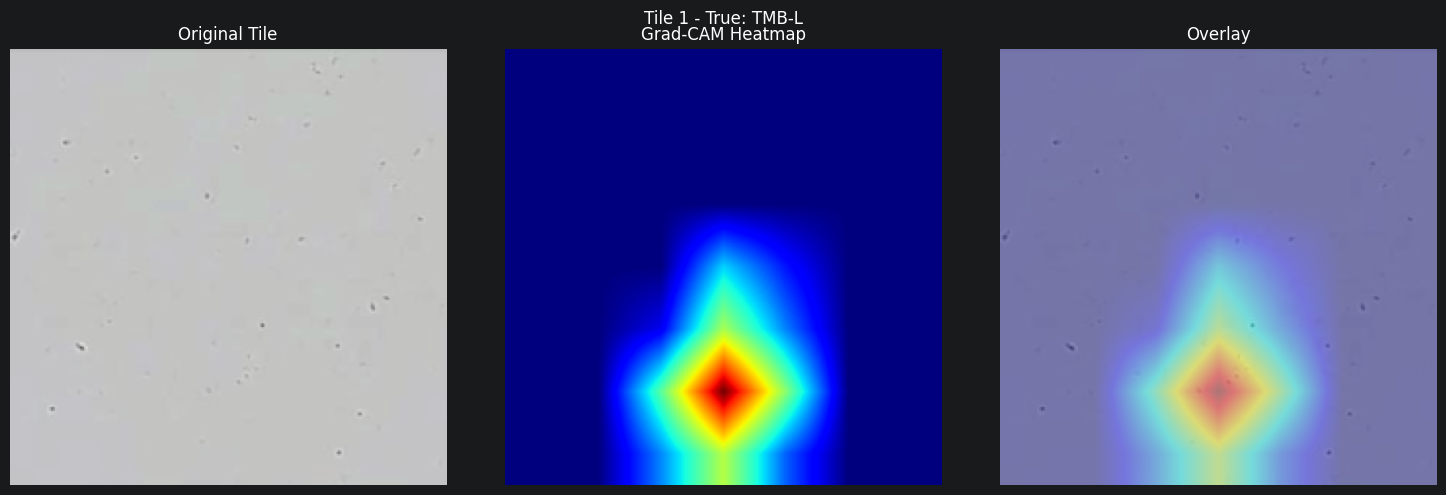

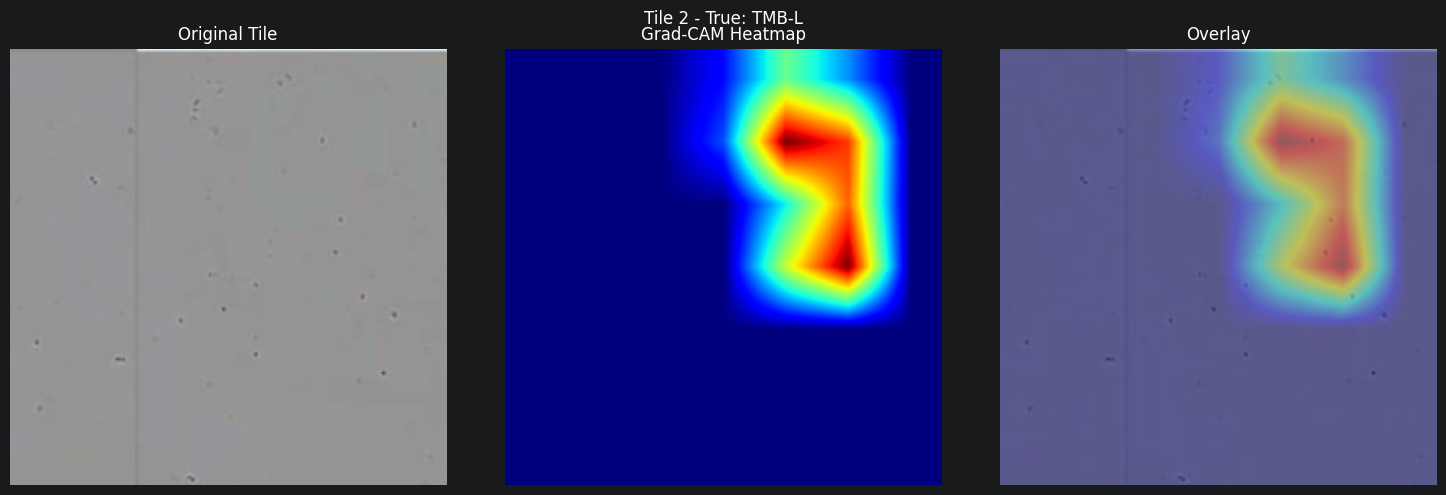

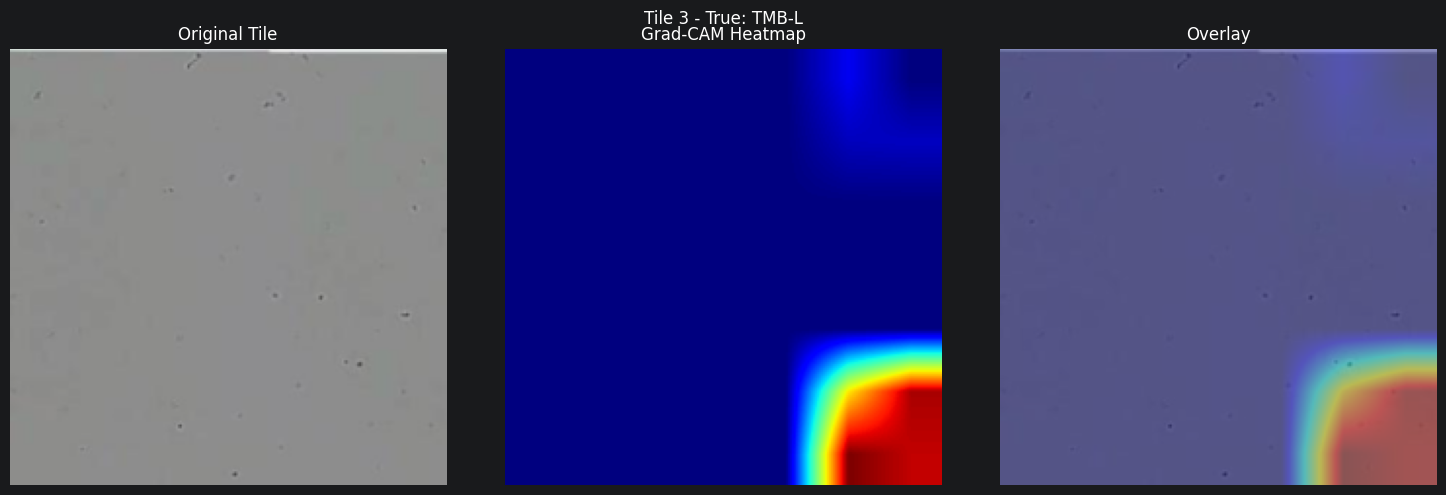


Generating SHAP image explanations...


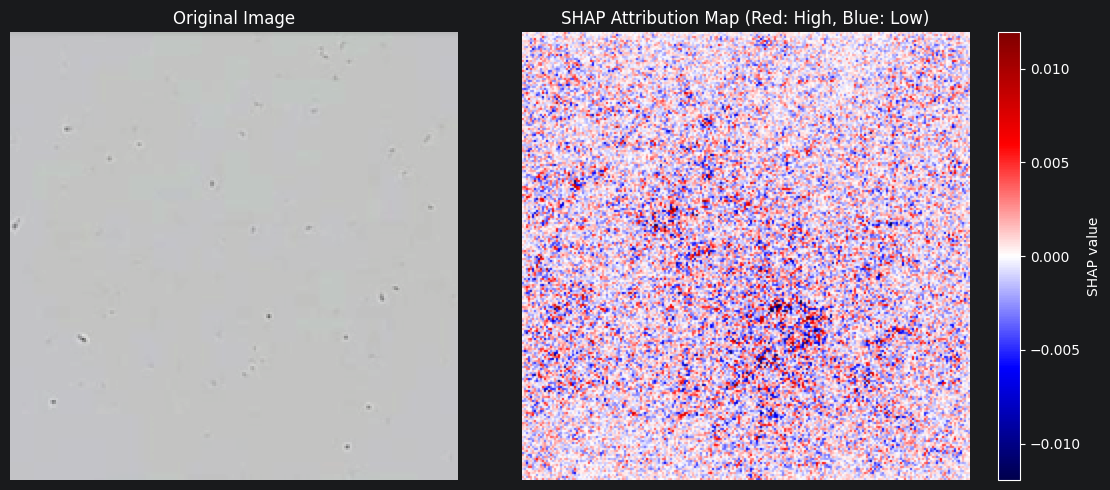


Generating SHAP clinical feature explanations...


100%|██████████| 50/50 [00:00<00:00, 257.87it/s]


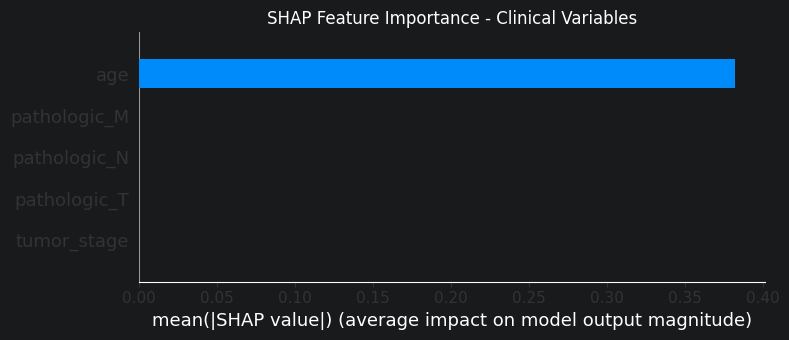


Generating LIME image explanation...


100%|██████████| 300/300 [00:00<00:00, 327.22it/s]


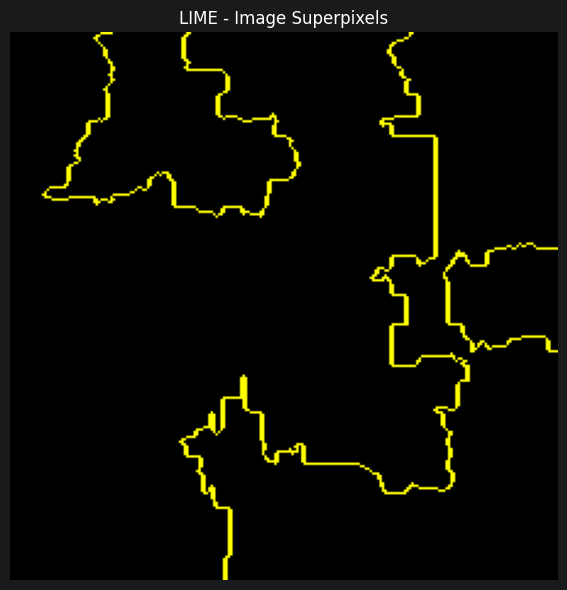


Generating LIME clinical explanation...


<Figure size 1000x600 with 0 Axes>

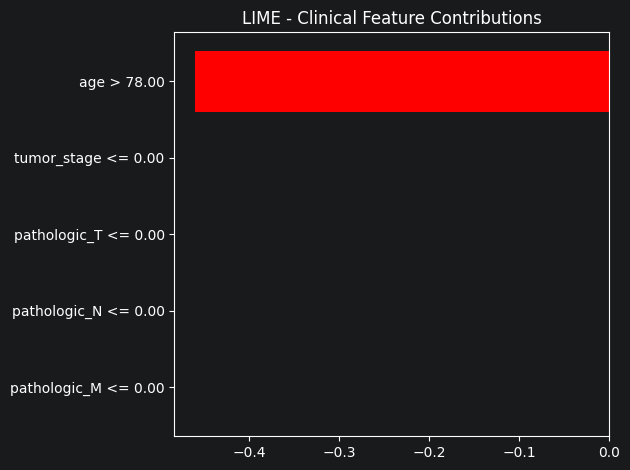


Computing Partial Dependence Plot...


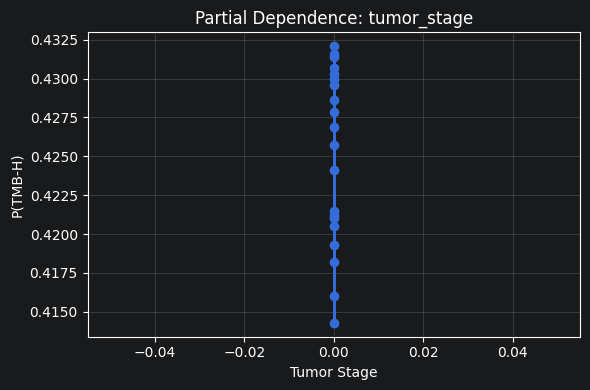


Computing clinical feature importance...


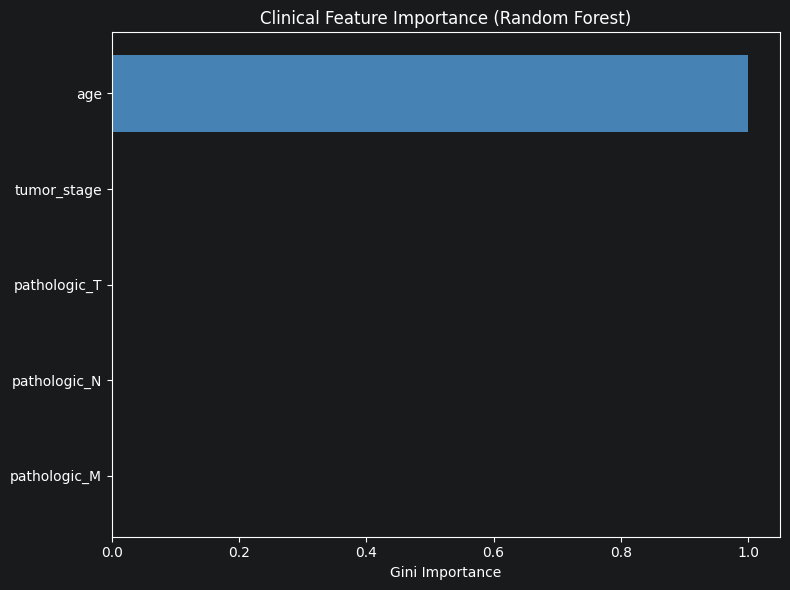


Running statistical comparison...

Statistical Comparison vs Paper Baseline (AUC=0.817):
Our mean AUC: 0.733 ± 0.000
One-sample t-test: t=nan, p=nan
Wilcoxon test: W=0.0, p=1.0000
○ No significant difference detected

✓ All outputs saved to: members/youssef/experiments/MultiModal/checkpoints
✓ Figures saved to: members/youssef/experiments/MultiModal/figures


In [11]:
# ## §11 — Main Execution

def main():
    """Main execution pipeline."""

    print(f"Project root: {PROJECT_ROOT}")

    # Load clinical data with TMB labels - try multiple sources
    label_candidates = [
        DATA_DIR / 'model_cohort.csv',
        PROJECT_ROOT / 'model_cohort.csv',
        DATA_DIR / 'cohort_phase2.csv',
        PROJECT_ROOT / 'cohort_phase2.csv',
        TABULAR_DIR / 'coad_tcga_gdc' / 'patient.tsv',
    ]

    clinical_df = None
    labels_path = None

    for candidate in label_candidates:
        if candidate.exists():
            labels_path = candidate
            try:
                if candidate.suffix == '.tsv':
                    clinical_df = pd.read_csv(candidate, sep='\t')
                else:
                    clinical_df = pd.read_csv(candidate)
                clinical_df.columns = [c.lower() for c in clinical_df.columns]
                break
            except Exception as e:
                print(f"Warning: Failed to load {candidate}: {e}")
                clinical_df = None
                continue

    if clinical_df is not None:
        # Create binary TMB label if not present
        if 'tmb_label' not in clinical_df.columns:
            if 'tmb_nonsynonymous' not in clinical_df.columns:
                raise ValueError(f"No TMB label column found in {labels_path}")
            clinical_df['tmb_label'] = (
                clinical_df['tmb_nonsynonymous'] >= CONFIG['tmb_threshold']
            ).astype(int)
        
        # Ensure top clinical features exist in the dataframe
        missing_features = [f for f in CONFIG['top_clinical_features'] if f not in clinical_df.columns]
        if missing_features:
             print(f"Warning: Missing clinical features in loaded data: {missing_features}. Using available columns.")
             # Update CONFIG with actually available features if needed, or handle missing
             # For now, we will add dummy columns if missing to satisfy the requirement
             for f in missing_features:
                 clinical_df[f] = 0

        clinical_df = clinical_df[['patient_id', 'tmb_label'] + CONFIG['top_clinical_features']].dropna().drop_duplicates('patient_id')
    else:
        print("Warning: Clinical labels not found. Creating synthetic demo data from available tiles.")
        # Demo mode: use actual patient folders at disk for synthetic labels
        available_patients = sorted([p.name for p in TILES_DIR.iterdir() if p.is_dir()])
        if not available_patients:
            raise FileNotFoundError(f"No patient folders found under {TILES_DIR}")
        available_patients = available_patients[:min(100, len(available_patients))]
        clinical_df = pd.DataFrame({
            'patient_id': available_patients,
            'tmb_label': np.random.randint(0, 2, size=len(available_patients)),
            'tumor_stage': np.random.choice(['Stage I', 'Stage II', 'Stage III', 'Stage IV'], size=len(available_patients)),
            'pathologic_T': np.random.choice(['T1', 'T2', 'T3', 'T4'], size=len(available_patients)),
            'pathologic_N': np.random.choice(['N0', 'N1', 'N2'], size=len(available_patients)),
            'pathologic_M': np.random.choice(['M0', 'M1'], size=len(available_patients)),
            'age': np.random.randint(40, 85, size=len(available_patients)),
        })

    # Encode categorical clinical features
    categorical_cols = ['tumor_stage', 'pathologic_T', 'pathologic_N', 'pathologic_M']
    for col in categorical_cols:
        if col in clinical_df.columns:
            clinical_df[col] = clinical_df[col].astype('category').cat.codes

    # Create dataloaders
    train_loader, val_loader, test_loader, clinical_feature_names = create_dataloaders(
        TILES_DIR, clinical_df, CONFIG['batch_size']
    )
    print(f"Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}, Test: {len(test_loader.dataset)}")
    print(f"Clinical features: {clinical_feature_names}")

    # Run multi-seed training
    output_dir = Path('members/youssef/experiments/MultiModal/checkpoints')
    output_dir.mkdir(parents=True, exist_ok=True)

    results_df, summary = run_multi_seed_evaluation(
        MMDL, train_loader, val_loader, test_loader,
        CONFIG, SEEDS, clinical_feature_names, output_dir
    )

    # Load best model for explainability
    print("\nLoading best model for explainability demos...")
    best_model = MMDL(num_clinical_features=len(clinical_feature_names),
                      num_classes=CONFIG['num_classes'])
    best_model.set_clinical_features(clinical_feature_names)
    
    # Try to load best model (seed 42)
    checkpoint_path = output_dir / 'best_model_seed42.pt'
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        best_model.load_state_dict(checkpoint['model_state_dict'])
    
    # Keep model on CPU for SHAP if possible, but the code later expects it on DEVICE
    # The error was because model was on CPU and inputs on CUDA in predict_clinical
    best_model = best_model.to(DEVICE)

    # Get test batch
    test_batch = next(iter(test_loader))
    test_imgs, test_clinical, test_labels = test_batch[0][:3].to(DEVICE), test_batch[1][:3], test_batch[2][:3]

    # === EXPLAINABILITY DEMOS ===

    # 1. Grad-CAM
    print("\nGenerating Grad-CAM visualizations...")
    for i in range(min(3, len(test_imgs))):
        heatmap, overlay = compute_gradcam_mmdl(best_model, test_imgs[i], test_clinical[i], device=DEVICE)
        if heatmap is not None:
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            orig = test_imgs[i].permute(1, 2, 0).cpu().numpy()
            orig = orig * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            axes[0].imshow(np.clip(orig, 0, 1))
            axes[0].set_title('Original Tile')
            axes[0].axis('off')
            axes[1].imshow(heatmap, cmap='jet')
            axes[1].set_title('Grad-CAM Heatmap')
            axes[1].axis('off')
            axes[2].imshow(overlay)
            axes[2].set_title('Overlay')
            axes[2].axis('off')
            plt.suptitle(f'Tile {i + 1} - True: TMB-{"H" if test_labels[i] == 1 else "L"}')
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / f'gradcam_tile{i + 1}.png', dpi=300)
            plt.show()

    # 2. SHAP - Image
    print("\nGenerating SHAP image explanations...")
    # Better background: take first 20 images from test set
    background_imgs = []
    for i, b in enumerate(test_loader):
        background_imgs.append(b[0])
        if i >= 4: break # 5 * batch_size images approx
    background_tensor = torch.cat(background_imgs, dim=0)[:50]
    
    test_img = test_imgs[0:1]
    shap_img = explain_shap_image(best_model, background_tensor, test_img, DEVICE)
    
    if shap_img is not None:
        # GradientExplainer output varies by SHAP version:
        #   - Older SHAP: list of arrays, one per output class → each (N, C, H, W)
        #   - Newer SHAP: single ndarray → (N, C, H, W, num_classes)
        # We always want the class-1 attribution for the positive class.

        if isinstance(shap_img, list):
            # List format: index 1 → class-1 attributions, shape (N, C, H, W)
            s_val = np.array(shap_img[1])  # (N, C, H, W)
        else:
            s_val = np.array(shap_img)     # could be (N, C, H, W, num_classes)
            if s_val.ndim == 5:
                # Last dim is num_classes; take class 1
                s_val = s_val[..., 1]      # (N, C, H, W)

        # Remove batch dim (N=1)
        if s_val.ndim == 4:
            s_val = s_val[0]               # (C, H, W)

        # Ensure channel-last layout (H, W, C) for summing
        if s_val.ndim == 3:
            if s_val.shape[0] == 3:        # (C, H, W) → (H, W, C)
                s_val = s_val.transpose(1, 2, 0)
            # else already (H, W, C) or (H, W, 1)
            shap_sum = s_val.sum(axis=-1)  # (H, W)
        elif s_val.ndim == 2:
            shap_sum = s_val               # already (H, W)
        else:
            shap_sum = s_val.reshape(s_val.shape[-2], s_val.shape[-1])

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        orig = test_img[0].permute(1, 2, 0).cpu().numpy()
        orig = orig * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        plt.imshow(np.clip(orig, 0, 1))
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        v_max = np.percentile(np.abs(shap_sum), 99.9)
        if v_max == 0:
            v_max = 1e-5
        plt.imshow(shap_sum, cmap='seismic', vmin=-v_max, vmax=v_max)
        plt.colorbar(label='SHAP value')
        plt.title('SHAP Attribution Map (Red: High, Blue: Low)')
        plt.axis('off')

        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'shap_image.png', dpi=300)
        plt.show()

    # 3. SHAP - Tabular
    print("\nGenerating SHAP clinical feature explanations...")
    shap_tab, feat_names = explain_shap_tabular(best_model, clinical_df, clinical_feature_names)
    if shap_tab is not None:
        plot_shap_summary(shap_tab, feat_names, FIGURES_DIR)

    # 4. LIME - Image
    print("\nGenerating LIME image explanation...")
    test_img_np = test_imgs[0].permute(1, 2, 0).cpu().numpy()
    test_img_np = test_img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    test_img_np = np.clip(test_img_np, 0, 1)

    lime_img = explain_lime_image(best_model, test_img_np, DEVICE, num_samples=300)
    if lime_img is not None:
        temp, mask = lime_img.get_image_and_mask(
            lime_img.top_labels[0], positive_only=True, num_features=10, hide_rest=False
        )
        plt.figure(figsize=(8, 6))
        plt.imshow(mark_boundaries(temp / 255.0, mask))
        plt.title(f'LIME - Image Superpixels')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'lime_image.png', dpi=300)
        plt.show()

    # 5. LIME - Tabular
    print("\nGenerating LIME clinical explanation...")
    lime_tab = explain_lime_tabular(best_model, clinical_df, clinical_feature_names, instance_idx=0)
    if lime_tab is not None:
        fig = plt.figure(figsize=(10, 6))
        lime_tab.as_pyplot_figure()
        plt.title('LIME - Clinical Feature Contributions')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'lime_clinical.png', dpi=300)
        plt.show()

    # 6. PDP for top clinical feature
    print("\nComputing Partial Dependence Plot...")
    top_feature = clinical_feature_names[0]  # e.g., 'tumor_stage'
    # Estimate range based on data type
    if clinical_df[top_feature].dtype in ['int64', 'int32', 'float64']:
        feat_min, feat_max = clinical_df[top_feature].min(), clinical_df[top_feature].max()
    else:
        feat_min, feat_max = 0, clinical_df[top_feature].nunique() - 1

    x_vals, pdp_vals = compute_pdp_clinical(
        best_model, clinical_df, top_feature,
        feature_range=(feat_min, feat_max), n_points=20
    )
    plot_pdp(x_vals, pdp_vals, top_feature, FIGURES_DIR)

    # 7. Feature Importance (Random Forest baseline)
    print("\nComputing clinical feature importance...")
    feat_imp = compute_clinical_feature_importance(clinical_df, clinical_feature_names)

    plt.figure(figsize=(8, 6))
    sorted_imp = sorted(feat_imp.items(), key=lambda x: x[1], reverse=True)
    names, values = zip(*sorted_imp)
    plt.barh(names, values, color='steelblue')
    plt.xlabel('Gini Importance')
    plt.title('Clinical Feature Importance (Random Forest)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'feature_importance_rf.png', dpi=300)
    plt.show()

    # Statistical comparison vs paper
    print("\nRunning statistical comparison...")
    # Paper reports AUC=0.817 for ResNet18+clinical (Fig 6a)
    stat_results = statistical_test(results_df.to_dict('records'), paper_baseline_auc=0.817)

    # Save summary
    import json
    summary_path = output_dir / 'final_summary.json'
    with open(summary_path, 'w') as f:
        json.dump({
            'multi_seed_summary': summary.to_dict(),
            'statistical_test': stat_results,
            'config': CONFIG,
            'clinical_features': clinical_feature_names,
        }, f, indent=2)

    print(f"\n✓ All outputs saved to: {output_dir}")
    print(f"✓ Figures saved to: {FIGURES_DIR}")

    return summary, stat_results


if __name__ == '__main__':
    main()
